**Carson Plett | 501042248 | ELE888 Lab 3**

**Part A -  Dataset 1**

In [1]:
A1 = (2, 10)
A2 = (2, 5)
A3 = (8, 4)
A4 = (5, 8)
A5 = (7, 5)
A6 = (6, 4)
A7 = (1, 2)
A8 = (4, 9)

In [2]:
import numpy as np
def euclidean_distance(point1, point2):
  return np.sqrt((point1[0]-point2[0])**2 + (point1[1]-point2[1])**2)

Distance Matrix

          A1        A2        A3        A4        A5        A6        A7  \
A1  0.000000  5.000000  8.485281  3.605551  7.071068  7.211103  8.062258   
A2  5.000000  0.000000  6.082763  4.242641  5.000000  4.123106  3.162278   
A3  8.485281  6.082763  0.000000  5.000000  1.414214  2.000000  7.280110   
A4  3.605551  4.242641  5.000000  0.000000  3.605551  4.123106  7.211103   
A5  7.071068  5.000000  1.414214  3.605551  0.000000  1.414214  6.708204   
A6  7.211103  4.123106  2.000000  4.123106  1.414214  0.000000  5.385165   
A7  8.062258  3.162278  7.280110  7.211103  6.708204  5.385165  0.000000   
A8  2.236068  4.472136  6.403124  1.414214  5.000000  5.385165  7.615773   

          A8  
A1  2.236068  
A2  4.472136  
A3  6.403124  
A4  1.414214  
A5  5.000000  
A6  5.385165  
A7  7.615773  
A8  0.000000  


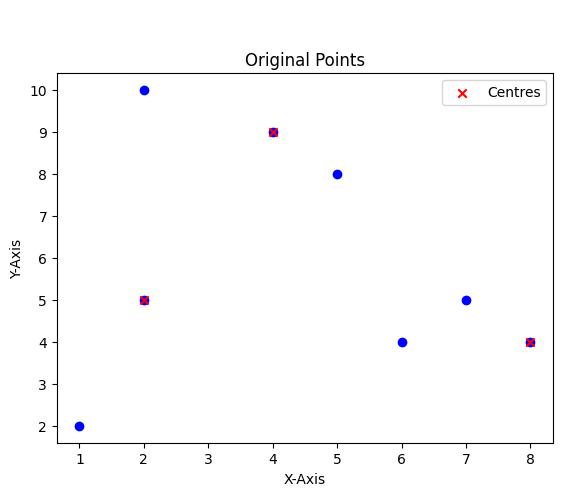

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

points = [A1, A2, A3, A4, A5, A6, A7, A8]
centres = [A2, A3, A8]
distance_matrix = np.zeros((8, 8))

for i in range(8):
  for j in range(8):
    distance_matrix[i, j] = euclidean_distance(points[i], points[j])

distance_df = pd.DataFrame(distance_matrix, columns=[f'A{i+1}' for i in range(8)], index=[f'A{i+1}' for i in range(8)])

print("Distance Matrix\n")
print(distance_df)

x_coordinates = [point[0] for point in points]
y_coordinates = [point[1] for point in points]
plt.scatter(x_coordinates, y_coordinates, color = 'blue', marker = 'o')

x_coordinates = [centre[0] for centre in centres]
y_coordinates = [centre[1] for centre in centres]
plt.scatter(x_coordinates, y_coordinates, label = 'Centres', color = 'red', marker = 'x')

plt.legend
plt.xlabel('X-Axis')
plt.ylabel('Y-Axis')
plt.title('\n\nOriginal Points')
plt.legend()
plt.show()

In [4]:
def calculate_clusters(points, centres):
  clusters = [[] for _ in range(len(centres))]
  for point in points:
    distances = [euclidean_distance(point, centre) for centre in centres]
    nearest_centre = np.argmin(distances)
    clusters[nearest_centre].append(point)
  return clusters

def calculate_centres(clusters, old_centres):
  new_centres = []
  for i, cluster in enumerate(clusters):
    if cluster:
      new_centres.append(tuple(np.mean(cluster, axis=0)))
    else:
      new_centres.append(old_centres[i])
  return new_centres

def k_means(points, centres, epochs):
    points = np.array(points)
    centres = np.array(centres)
    for _ in range(epochs):
      clusters = calculate_clusters(points, centres)
      new_centres = calculate_centres(clusters, centres)
      if np.allclose(centres, new_centres):
        print("Converged at ", _)
        break
      centres = np.array(new_centres)
    return clusters, centres

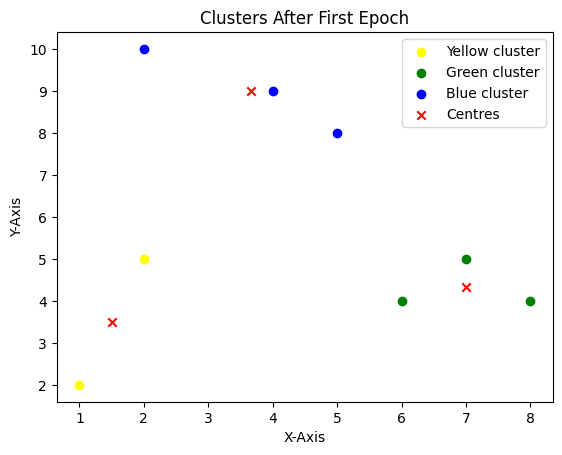

The new centres are: ['(1.50, 3.50)', '(7.00, 4.33)', '(3.67, 9.00)']


In [5]:
# Set-up points and initial centres
points = [A1, A2, A3, A4, A5, A6, A7, A8]
centres = [A2, A3, A8]
epochs = 1

# Run k-means through first epoch
clusters, new_centres = k_means(points, centres, epochs)

# Plot different clusters in different colors
colors = ['Yellow', 'Green', 'Blue']
count = 1
for cluster, color in zip(clusters, colors):
  x_coordinates = [point[0] for point in cluster]
  y_coordinates = [point[1] for point in cluster]
  plt.scatter(x_coordinates, y_coordinates, label = f'{color} cluster', color=color, marker='o')

# Plot centres
x_coordinates = [centre[0] for centre in new_centres]
y_coordinates = [centre[1] for centre in new_centres]

plt.scatter(x_coordinates, y_coordinates, label = 'Centres', color = 'red', marker = 'x')
plt.xlabel('X-Axis')
plt.ylabel('Y-Axis')
plt.title('Clusters After First Epoch')
plt.legend()
plt.show()

print(f"The new centres are: {[f'({x:.2f}, {y:.2f})' for x, y in new_centres]}")

**Questions 1 - 5**
Q1 - The new clusters are shown above represented in unique colours.
Q2 - The new centres of the clusters are indicated by red 'x'es in the figure above.
Q3 - The figure is presented above.
Q4 - The first epoch was enough to attain convergence.
Q5 - A subsequent iteration is presented below for confirmation.

Converged at  1


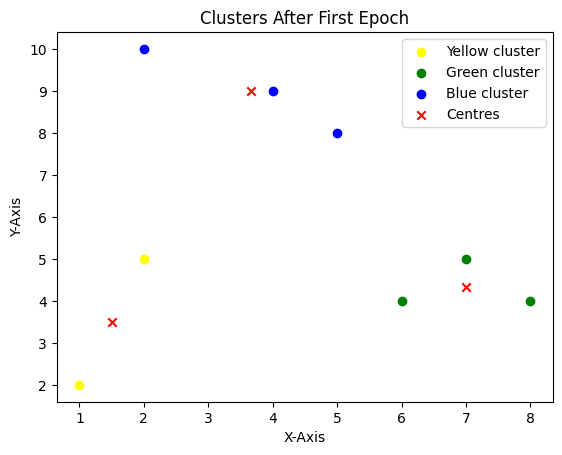

The new centres are: ['(1.50, 3.50)', '(7.00, 4.33)', '(3.67, 9.00)']


In [6]:
# Set-up points and initial centres
points = [A1, A2, A3, A4, A5, A6, A7, A8]
centres = [A2, A3, A8]
epochs = 2

# Run k-means through two epochs
clusters, new_centres = k_means(points, centres, epochs)

# Plot different clusters in different colors
colors = ['Yellow', 'Green', 'Blue']
for cluster, color in zip(clusters, colors):
  x_coordinates = [point[0] for point in cluster]
  y_coordinates = [point[1] for point in cluster]
  plt.scatter(x_coordinates, y_coordinates, label = f'{color} cluster', color=color, marker='o')

# Plot centres
x_coordinates = [centre[0] for centre in new_centres]
y_coordinates = [centre[1] for centre in new_centres]
plt.scatter(x_coordinates, y_coordinates, label = 'Centres', color = 'red', marker = 'x')

plt.xlabel('X-Axis')
plt.ylabel('Y-Axis')
plt.title('Clusters After First Epoch')
plt.legend()
plt.show()

print(f"The new centres are: {[f'({x:.2f}, {y:.2f})' for x, y in new_centres]}")

Since there was no change in this second epoch, the centres have converged and would not change for any number of subsequent epochs.

**Verifying with sklearn (Part D)**

In [7]:
from sklearn.cluster import KMeans

points = [A1, A2, A3, A4, A5, A6, A7, A8]
centers = [A2, A3, A8]

data = np.array(points)

kmeans = KMeans(n_clusters=3, init=np.array(centers), n_init=1, random_state=42)
kmeans.fit(data)

labels = kmeans.labels_
print(f"The KMeans cluster labels are: {labels}")
print(f"The new centers are: {[f'({x:.2f}, {y:.2f})' for (x, y) in kmeans.cluster_centers_]}")

The KMeans cluster labels are: [2 0 1 2 1 1 0 2]
The new centers are: ['(1.50, 3.50)', '(7.00, 4.33)', '(3.67, 9.00)']


K-means with respect to Part A, Dataset 1 was successfully verified (see above).

**Part A - Dataset 2**

In [8]:
import pandas as pd

url = 'https://raw.githubusercontent.com/tofighi/MachineLearning/master/datasets/heart.csv'
data = pd.read_csv(url)
normalized_data = data[['sbp', 'tobacco']]

mean_values = normalized_data.mean()
std_values = normalized_data.std()
normalized_data = (normalized_data - mean_values) / std_values
normalized_data['chd'] = data['chd']

print(data)
print(normalized_data)

     row.names  sbp  tobacco    ldl  adiposity  famhist  typea  obesity  \
0            1  160    12.00   5.73      23.11  Present     49    25.30   
1            2  144     0.01   4.41      28.61   Absent     55    28.87   
2            3  118     0.08   3.48      32.28  Present     52    29.14   
3            4  170     7.50   6.41      38.03  Present     51    31.99   
4            5  134    13.60   3.50      27.78  Present     60    25.99   
..         ...  ...      ...    ...        ...      ...    ...      ...   
457        459  214     0.40   5.98      31.72   Absent     64    28.45   
458        460  182     4.20   4.41      32.10   Absent     52    28.61   
459        461  108     3.00   1.59      15.23   Absent     40    20.09   
460        462  118     5.40  11.61      30.79   Absent     64    27.35   
461        463  132     0.00   4.82      33.41  Present     62    14.70   

     alcohol  age  chd  
0      97.20   52    1  
1       2.06   63    1  
2       3.81   46    0  

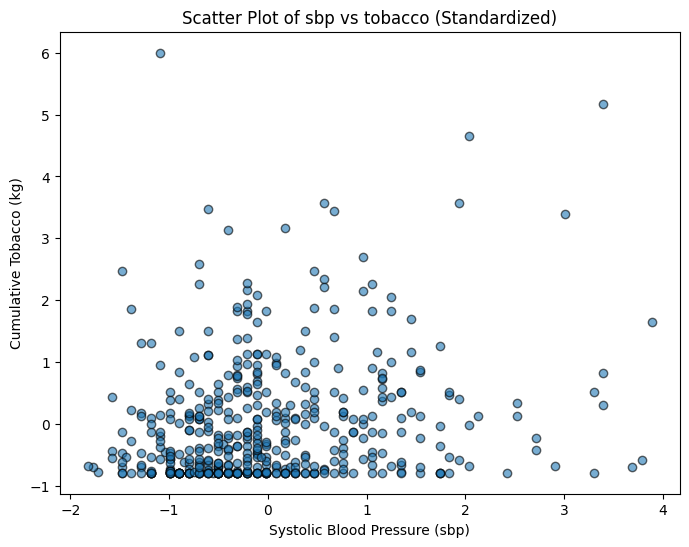

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(normalized_data['sbp'], normalized_data['tobacco'], alpha=0.6, edgecolors='k')

plt.xlabel("Systolic Blood Pressure (sbp)")
plt.ylabel("Cumulative Tobacco (kg)")
plt.title("Scatter Plot of sbp vs tobacco (Standardized)")

plt.show()

Converged at  5
The centres are at: ['(0.66, 0.84)', '(-0.56, -0.47)']


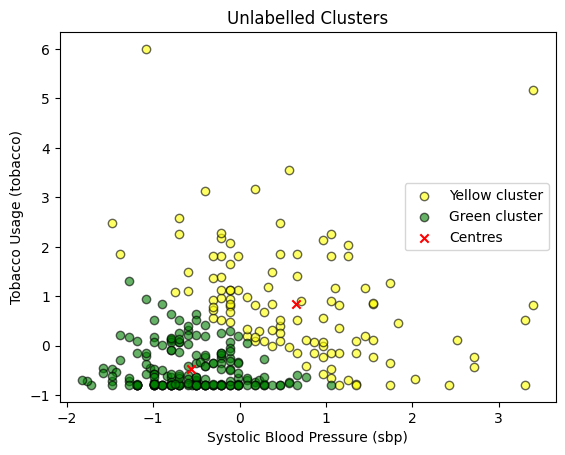

In [10]:
import random

# Generate random starting points
points = [tuple(x) for x in normalized_data[['sbp', 'tobacco']].iloc[:300].values]
centres = random.sample(points, 2)
epochs = 50

# Run k-means until convergence or 50 epochs
clusters, centres = k_means(points, centres, epochs)

# Print centers for later comparison with sklearn k-means
print(f"The centres are at: {[f'({x:.2f}, {y:.2f})' for x, y in centres]}")

# Plot resulting clusters
colors = ['Yellow', 'Green']
for cluster, color in zip(clusters, colors):
  x_coordinates = [point[0] for point in cluster]
  y_coordinates = [point[1] for point in cluster]
  plt.scatter(x_coordinates, y_coordinates, label = f'{color} cluster', color = color, alpha=0.6, edgecolor='k')

# Plot centres
x_coordinates = [centre[0] for centre in centres]
y_coordinates = [centre[1] for centre in centres]
plt.scatter(x_coordinates, y_coordinates, label = 'Centres', color = 'red', marker = 'x')

plt.xlabel('Systolic Blood Pressure (sbp)')
plt.ylabel('Tobacco Usage (tobacco)')
plt.title('Unlabelled Clusters')
plt.legend()
plt.show()

After at most 20 epochs, the k-means algorithm seems to render similar results even after numerous trials with k equal to 2 on the 300 first samples from the data. Since both an increase in both sbp and tobacco were seen to be positively correlated with chd in Lab 2, the cluster occupying the top right portion of the plot above will be predicted to be positive for chd, and the other cluster, negative. The last 162 samples will be grouped according to these two centres and therein the accuracy estimated.

**Verifying with sklearn (Part D)**

In [11]:
points = [tuple(x) for x in normalized_data[['sbp', 'tobacco']].iloc[:300].values]
centers = random.sample(points, 2)

data = np.array(points)

kmeans = KMeans(n_clusters=2, init=np.array(centers), n_init=1, random_state=42)
kmeans.fit(data)

print(f"The centres are at: {[f'({x:.2f}, {y:.2f})' for (x, y) in kmeans.cluster_centers_]}")

The centres are at: ['(-0.56, -0.47)', '(0.66, 0.84)']


Again, the trial by sklearn yields similar results to what was found through manual calculations, that is, the cluster centers from both trials are very close.

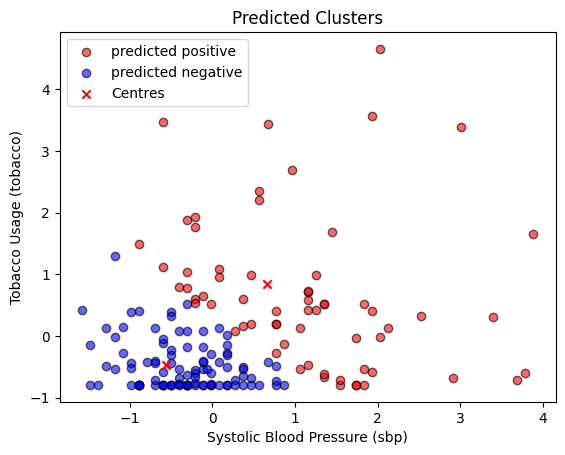

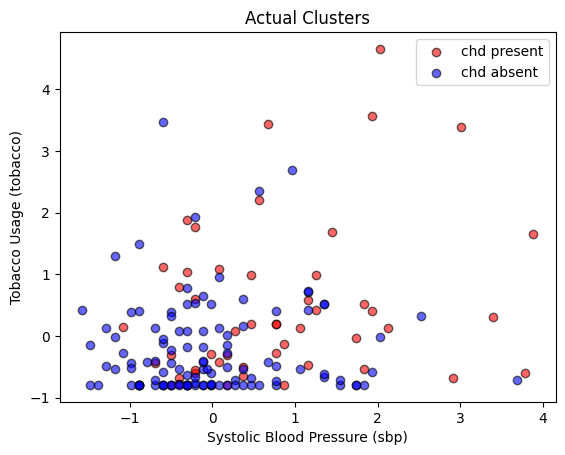

In [12]:
points = [tuple(x) for x in normalized_data[['sbp', 'tobacco']].iloc[-162:].values]
epochs = 1

# Run k-means using centres obtained previously
clusters, new_centres = k_means(points, centres, epochs)

# Decide whether predicted positive cluster is index 0 or 1
if new_centres[0][0] > new_centres[1][0] and new_centres[0][1] > new_centres[1][1]:
  positive_index = 0
  negative_index = 1
else:
  positive_index = 1
  negative_index = 0

# Assign points to predicted_positive or predicted_negative
predicted_positive = clusters[positive_index]
predicted_negative = clusters[negative_index]

# Plot predicted_positive
plt.scatter(
  [point[0] for point in predicted_positive],
  [point[1] for point in predicted_positive],
  color='red', alpha=0.6, edgecolor='k', label='predicted positive'
)
# Plot predicted_negative
plt.scatter(
  [point[0] for point in predicted_negative],
  [point[1] for point in predicted_negative],
  color='blue', alpha=0.6, edgecolor='k', label='predicted negative'
)

# Plot centres
x_coordinates = [centre[0] for centre in centres]
y_coordinates = [centre[1] for centre in centres]
plt.scatter(x_coordinates, y_coordinates, label = 'Centres', color = 'red', marker = 'x')

# Show plot
plt.xlabel('Systolic Blood Pressure (sbp)')
plt.ylabel('Tobacco Usage (tobacco)')
plt.title('Predicted Clusters')
plt.legend()
plt.show()

# Plot actual chd data for comparison
sbp = normalized_data['sbp'].iloc[-162:].values
tobacco = normalized_data['tobacco'].iloc[-162:].values
chd = normalized_data['chd'].iloc[-162:].values

chd_present = [(sbp[i], tobacco[i]) for i in range(len(sbp)) if chd[i] == 1]
chd_absent = [(sbp[i], tobacco[i]) for i in range(len(sbp)) if chd[i] == 0]

# Plot chd present
plt.scatter(
  [point[0] for point in chd_present],
  [point[1] for point in chd_present],
  color='red', alpha=0.6, edgecolor='k', label='chd present'
)
# Plot chd absent
plt.scatter(
  [point[0] for point in chd_absent],
  [point[1] for point in chd_absent],
  color='blue', alpha=0.6, edgecolor='k', label='chd absent'
)
plt.xlabel('Systolic Blood Pressure (sbp)')
plt.ylabel('Tobacco Usage (tobacco)')
plt.title('Actual Clusters')
plt.legend()
plt.show()

In [13]:
import numpy as np

true_positive = 0
false_positive = 0
true_negative = 0
false_negative = 0

# Ensure predicted_positive and predicted_negative are lists of NumPy arrays for comparison
predicted_positive = [np.array(point) for point in predicted_positive]
predicted_negative = [np.array(point) for point in predicted_negative]

for i in range(len(points)):
    point = np.array(points[i])  # Convert the current point to a NumPy array

    # If chd is present (ground truth 1)
    if chd[i] == 1:
        # Truthfully predicted positive
        if any((point == p).all() for p in predicted_positive):
            true_positive += 1
        # Falsely predicted negative
        else:
            false_negative += 1
    # If chd is absent (ground truth 0)
    else:
        # Falsely predicted positive
        if any((point == p).all() for p in predicted_positive):
            false_positive += 1
        # Truthfully predicted negative
        else:
            true_negative += 1

# Output the results
print(f"True Negatives: {true_negative}")
print(f"True Positives: {true_positive}")
print(f"False Negatives: {false_negative}")
print(f"False Positives: {false_positive}")

accuracy = 100*(true_positive + true_negative)/(true_positive + true_negative + false_negative + false_positive)
print(f'The accuracy was calculated as approximately {accuracy:.2f}')

True Negatives: 82
True Positives: 34
False Negatives: 16
False Positives: 30
The accuracy was calculated as approximately 71.60


**Questions 6-8** Q6 - The accuracy was calculated as being approximately 70%. Q7 - The actual data points were presented above within the plot titled, 'Actual Clusters.' Q8 - The predicted data was plotted as, 'Predicted Clusters.'

**Part B - Dataset 1**

In [14]:
A1 = (2, 10)
A2 = (2, 5)
A3 = (8, 4)
A4 = (5, 8)
A5 = (7, 5)
A6 = (6, 4)
A7 = (1, 2)
A8 = (4, 9)

print("Distance Matrix\n")
print(distance_df)

Distance Matrix

          A1        A2        A3        A4        A5        A6        A7  \
A1  0.000000  5.000000  8.485281  3.605551  7.071068  7.211103  8.062258   
A2  5.000000  0.000000  6.082763  4.242641  5.000000  4.123106  3.162278   
A3  8.485281  6.082763  0.000000  5.000000  1.414214  2.000000  7.280110   
A4  3.605551  4.242641  5.000000  0.000000  3.605551  4.123106  7.211103   
A5  7.071068  5.000000  1.414214  3.605551  0.000000  1.414214  6.708204   
A6  7.211103  4.123106  2.000000  4.123106  1.414214  0.000000  5.385165   
A7  8.062258  3.162278  7.280110  7.211103  6.708204  5.385165  0.000000   
A8  2.236068  4.472136  6.403124  1.414214  5.000000  5.385165  7.615773   

          A8  
A1  2.236068  
A2  4.472136  
A3  6.403124  
A4  1.414214  
A5  5.000000  
A6  5.385165  
A7  7.615773  
A8  0.000000  


In [15]:
from collections import Counter
# Algorithm for nearest neighbors clustering
# Used during training
def nearest_neighbour(points, threshold):
  clusters = []
  point_to_add = points.pop(0)
  clusters.append([point_to_add])
  while points:
    point_to_add = points.pop(0)
    smallest_distance = threshold
    cluster_index = None
    for i, cluster in enumerate(clusters):
      for point in cluster:
        distance = euclidean_distance(point_to_add, point)
        if distance < smallest_distance:
          cluster_index = i
          smallest_distance = distance
    if cluster_index is not None:
      clusters[cluster_index].append(point_to_add)
    else:
      clusters.append([point_to_add])
  return clusters

# Algorithm for k-nearest neighbors (for classification)
# Used during testing
max = 100
def k_nearest_neighbour(initial_clusters, points, k):
  predictions = [[] for cluster in initial_clusters]
  for point_to_add in points:
    distances = []
    for i, cluster in enumerate(initial_clusters):
      for point in cluster:
        distance = euclidean_distance(point_to_add, point)
        distances.append((distance, i))
    distances.sort()
    k_nearest = distances[:k]
    k_nearest_labels = [i for _, i in k_nearest]
    most_common = Counter(k_nearest_labels).most_common(1)[0][0]
    predictions[most_common].append(point_to_add)
  return predictions

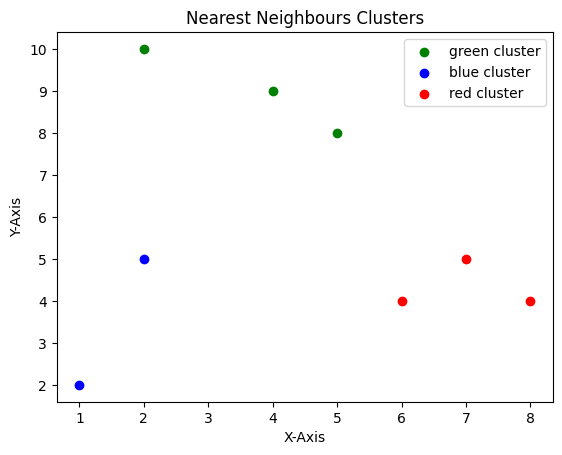

In [16]:
points = [A1, A2, A3, A4, A5, A6, A7, A8]
threshold = 4
clusters = []
clusters = nearest_neighbour(points, threshold)
colors = ['green', 'blue', 'red']
for cluster, color in zip(clusters, colors):
  x_coordinates = [point[0] for point in cluster]
  y_coordinates = [point[1] for point in cluster]
  plt.scatter(x_coordinates, y_coordinates, label = f'{color} cluster', color=color, marker='o')
plt.xlabel('X-Axis')
plt.ylabel('Y-Axis')
plt.title('Nearest Neighbours Clusters')
plt.legend()
plt.show()

**Questions 9 - 11** Q9 - Evidently, the nearest neighbour algorithm retrieved the same response as that response of the k-means algorithm.
Q10 - The final plot is presented above as 'Nearest Neighbours Clusters.'
Q11 - K-means partitions data into k clusters attempting to minimize intra-cluster variance. It works well with well separated data. It struggles with convergence on datasets that are not naturally clustered. It has repetitive updates to its 'centroids' which could lead to inefficiency with respect to larger datasets, i.e. it is constantly calculating averages with respect to numerous points. Nearest neighbours groups points based on their proximity to other points. It becomes computationally intensive with larger datasets as it is constantly calculating euclidean distances between points. This is its disadvantage.

**Verifying with sklearn (Part D)**

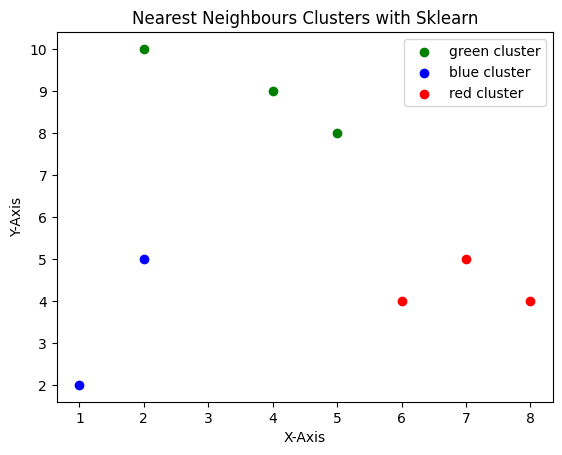

In [17]:
from sklearn.neighbors import NearestNeighbors

points = [A1, A2, A3, A4, A5, A6, A7, A8]
points = np.array(points)
threshold = 4

nbrs = NearestNeighbors(n_neighbors=len(points), radius=threshold)
nbrs.fit(points)

distances, indices = nbrs.radius_neighbors(points)

clusters = []
visited = set()
for i, neighbors in enumerate(indices):
  if i not in visited:
    cluster = set(neighbors)
    clusters.append(list(cluster))
    visited.update(cluster)

colors = ['green', 'blue', 'red']
for cluster, color in zip(clusters, colors):
  x_coordinates = [points[point][0] for point in cluster]
  y_coordinates = [points[point][1] for point in cluster]
  plt.scatter(x_coordinates, y_coordinates, label = f'{color} cluster', color=color, marker='o')
plt.xlabel('X-Axis')
plt.ylabel('Y-Axis')
plt.title('Nearest Neighbours Clusters with Sklearn')
plt.legend()
plt.show()

Once again, sklearn confirms the manual calculations.

**Part B - Dataset 2**

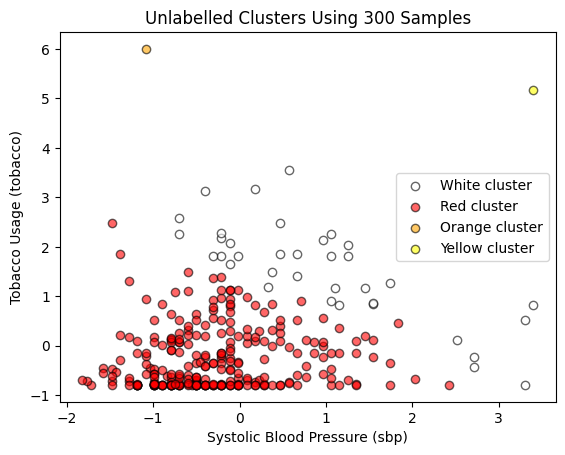

In [18]:
# Train clusters on first 300 samples
threshold = 2
clusters = []
points = [tuple(x) for x in normalized_data[['sbp', 'tobacco']].iloc[:300].values]
clusters = nearest_neighbour(points, threshold)

# Plot resulting clusters
colors = ['White', 'Red', 'Orange', 'Yellow', 'Green', 'Blue', 'Purple', 'Black', 'Grey']
for cluster, color in zip(clusters, colors):
  x_coordinates = [point[0] for point in cluster]
  y_coordinates = [point[1] for point in cluster]
  plt.scatter(x_coordinates, y_coordinates, label = f'{color} cluster', color = color, alpha=0.6, edgecolor='k')

plt.xlabel('Systolic Blood Pressure (sbp)')
plt.ylabel('Tobacco Usage (tobacco)')
plt.title('Unlabelled Clusters Using 300 Samples')
plt.legend()
plt.show()

The nearest neighbours algorithm implemented in this project was intended to imitate the nearest neighbours clustering algorithm presented on D2L. I believe this implementation might differ from other nearest neighbours clustering algorithms. The primary difference would be that my algorithm does not merge clusters based on distance if they have points that are within the threshold. It merely seeks the nearest neighbour from the points already clustered, and if the distance to that nearest neighbour is smaller than the threshold, it assigns this new point to that cluster containing the new point's nearest neighbour. That being said, I believe my algorithm implements the structure of the nearest neighbours algorithm presented on D2L.

Additionally, it should be noted that the threshold of 2 was observed to generate a pattern categorizing the training samples roughly into two groupings. As the intent of this investigation was to see how accurately we could predict chd from a nearest neighbour clustering algorithm, and as such, we needed the data partitioned into two clusters, the threshold of 2 was adopted.

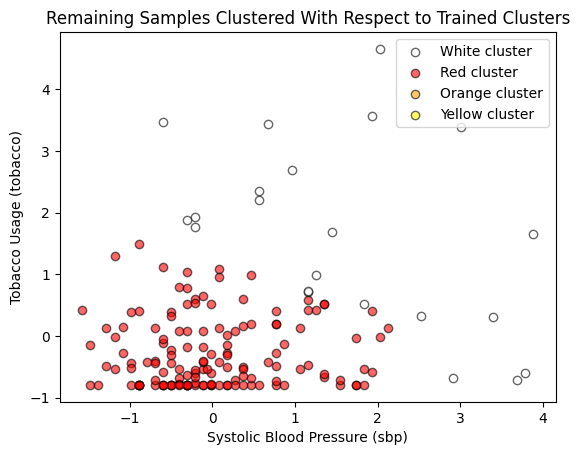

In [19]:
# Test subsequent 162 samples using clusters generated previously
threshold = 2
k = 3
points = [tuple(x) for x in normalized_data[['sbp', 'tobacco']].iloc[-162:].values]
clusters = k_nearest_neighbour(clusters, points, k)

# Plot resulting clusters
centres = []
colors = ['White', 'Red', 'Orange', 'Yellow', 'Green', 'Blue', 'Purple', 'Black', 'Grey']
for cluster, color in zip(clusters, colors):
  x_coordinates = [point[0] for point in cluster]
  y_coordinates = [point[1] for point in cluster]
  plt.scatter(x_coordinates, y_coordinates, label = f'{color} cluster', color = color, alpha=0.6, edgecolor='k')

plt.xlabel('Systolic Blood Pressure (sbp)')
plt.ylabel('Tobacco Usage (tobacco)')
plt.title('Remaining Samples Clustered With Respect to Trained Clusters')
plt.legend()
plt.show()

Again, the assumption was made that since both tobacco and sbp were positively correlated with chd, the group of points rougly situated in the upper right quadrant of the plot above were predicted positive for chd. Any points that were outliers in the upper right quadrant were included in the predicted positive grouping. The remainder was predicted negative for chd.

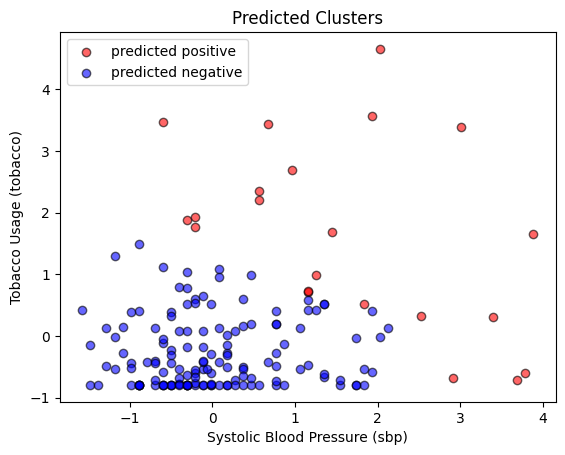

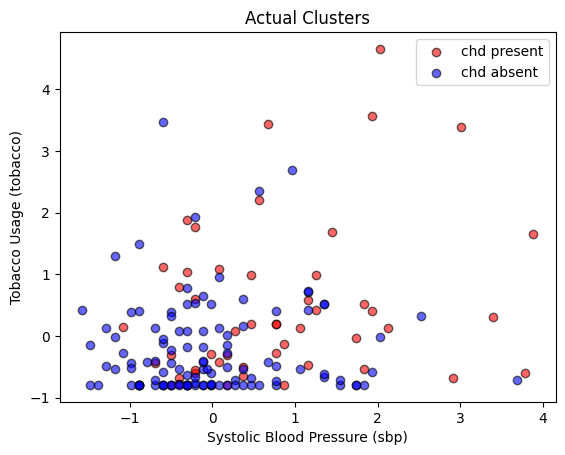

In [20]:
# Assign points to predicted_positive or predicted_negative
predicted_positive = clusters[0] + clusters[3]
predicted_negative = clusters[1]

# Plot predicted_positive
plt.scatter(
  [point[0] for point in predicted_positive],
  [point[1] for point in predicted_positive],
  color='red', alpha=0.6, edgecolor='k', label='predicted positive'
)
# Plot predicted_negative
plt.scatter(
  [point[0] for point in predicted_negative],
  [point[1] for point in predicted_negative],
  color='blue', alpha=0.6, edgecolor='k', label='predicted negative'
)

# Show plot
plt.xlabel('Systolic Blood Pressure (sbp)')
plt.ylabel('Tobacco Usage (tobacco)')
plt.title('Predicted Clusters')
plt.legend()
plt.show()

# Plot actual chd data for comparison
sbp = normalized_data['sbp'].iloc[-162:].values
tobacco = normalized_data['tobacco'].iloc[-162:].values
chd = normalized_data['chd'].iloc[-162:].values

chd_present = [(sbp[i], tobacco[i]) for i in range(len(sbp)) if chd[i] == 1]
chd_absent = [(sbp[i], tobacco[i]) for i in range(len(sbp)) if chd[i] == 0]

# Plot chd present
plt.scatter(
  [point[0] for point in chd_present],
  [point[1] for point in chd_present],
  color='red', alpha=0.6, edgecolor='k', label='chd present'
)
# Plot chd absent
plt.scatter(
  [point[0] for point in chd_absent],
  [point[1] for point in chd_absent],
  color='blue', alpha=0.6, edgecolor='k', label='chd absent'
)
plt.xlabel('Systolic Blood Pressure (sbp)')
plt.ylabel('Tobacco Usage (tobacco)')
plt.title('Actual Clusters')
plt.legend()
plt.show()

In [21]:
true_positive = 0
false_positive = 0
true_negative = 0
false_negative = 0

points = [tuple(x) for x in normalized_data[['sbp', 'tobacco']].iloc[-162:].values]
predicted_positive = [np.array(point) for point in predicted_positive]
predicted_negative = [np.array(point) for point in predicted_negative]

for i in range(len(points)):
    point = np.array(points[i])
    # chd is present
    if chd[i] == 1:
        # Truthfully predicted positive
        if any((point == p).all() for p in predicted_positive):
            true_positive += 1
        # Falsely predicted negative
        else:
            false_negative += 1
    # chd is absent
    else:
        # Falsely predicted positive
        if any((point == p).all() for p in predicted_positive):
            false_positive += 1
        # Truthfully predicted negative
        else:
            true_negative += 1

print(f"True Negatives: {true_negative}")
print(f"True Positives: {true_positive}")
print(f"False Negatives: {false_negative}")
print(f"False Positives: {false_positive}")

accuracy = 100*(true_positive + true_negative)/(true_positive + true_negative + false_negative + false_positive)
print(f'The accuracy was calculated as approximately {accuracy:.2f}')

True Negatives: 104
True Positives: 14
False Negatives: 36
False Positives: 8
The accuracy was calculated as approximately 72.84


**Question 12** Q12 - The accuracy was again calculated and was found to be just above 72%.

**Verifying with sklearn (Part D)**

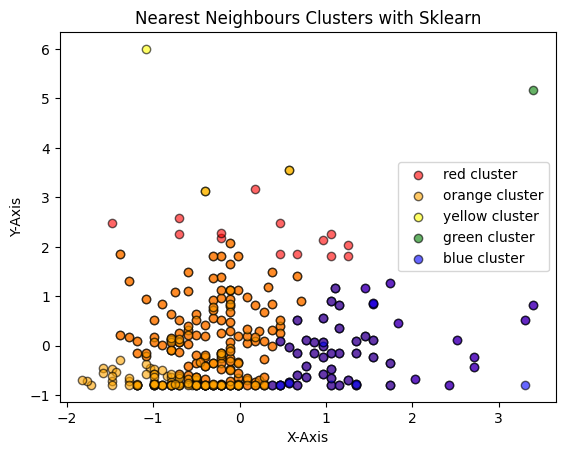

In [22]:
points = [tuple(x) for x in normalized_data[['sbp', 'tobacco']].iloc[:300].values]
points = np.array(points)
threshold = 3

nbrs = NearestNeighbors(n_neighbors=len(points), metric='euclidean', algorithm='ball_tree', radius=threshold)
nbrs.fit(points)

distances, indices = nbrs.radius_neighbors(points)

clusters = []
visited = set()
for i, neighbors in enumerate(indices):
  if i not in visited:
    cluster = set(neighbors)
    clusters.append(list(cluster))
    visited.update(cluster)

colors = ['red', 'orange', 'yellow', 'green', 'blue', 'purple', 'white', 'black']
for cluster, color in zip(clusters, colors):
  x_coordinates = [points[point][0] for point in cluster]
  y_coordinates = [points[point][1] for point in cluster]
  plt.scatter(x_coordinates, y_coordinates, alpha=0.6, edgecolor='k', label = f'{color} cluster', color=color, marker='o')
plt.xlabel('X-Axis')
plt.ylabel('Y-Axis')
plt.title('Nearest Neighbours Clusters with Sklearn')
plt.legend()
plt.show()

The results from Sklearn's nearest neighbours clustering appear to be different to those that were generated manually. This is likely the result of a difference in implementation, assumptions, or parameters. I believe my implementation is referred to as a greedy, incremental, single linkage clustering algorithm. It doesn't consider the case where there are multiple points within the threshold that are apart of multiple clusters. It simply adds the point-to-be-added to the cluster containing the nearest neighbor.

**Part C - Dataset 1**

In [23]:
A1 = (2, 10)
A2 = (2, 5)
A3 = (8, 4)
A4 = (5, 8)
A5 = (7, 5)
A6 = (6, 4)
A7 = (1, 2)
A8 = (4, 9)
points = [A1, A2, A3, A4, A5, A6, A7, A8]

In [24]:
def get_neighbors(point, points, epsilon):
    return [p for p in points if euclidean_distance(point, p) <= epsilon]

def euclidean_distance(p1, p2):
    return ((p1[0] - p2[0]) ** 2 + (p1[1] - p2[1]) ** 2) ** 0.5

def dbscan(points, epsilon, minpoints):
  clusters = []
  unvisited = points
  noise = []
  while unvisited:
    point_to_add = unvisited.pop()
    neighbors = get_neighbors(point_to_add, points, epsilon)
    if len(neighbors) + 1 >= minpoints:
      cluster = [point_to_add]
      while neighbors:
        point_to_add = neighbors.pop()
        unvisited.remove(point_to_add)
        cluster.append(point_to_add)
        new_neighbors = get_neighbors(point_to_add, points, epsilon)
        if len(neighbors) + 1 >= minpoints:
          for point in new_neighbors:
            if point not in neighbors:
              neighbors.append(point)
      clusters.append(cluster)
    else:
      noise.append(point_to_add)
  return clusters, noise

def dbscan_classification(initial_clusters, points, epsilon):
  clusters = [[] for cluster in initial_clusters]
  noise = []
  for point_to_add in points:
    assigned = False
    for i, cluster in enumerate(initial_clusters):
      for point in cluster:
        if euclidean_distance(point_to_add, point) < epsilon:
          clusters[i].append(point_to_add)
          assigned = True
          break
      if assigned:
        break
    if not assigned:
      noise.append(point_to_add)
  return clusters, noise

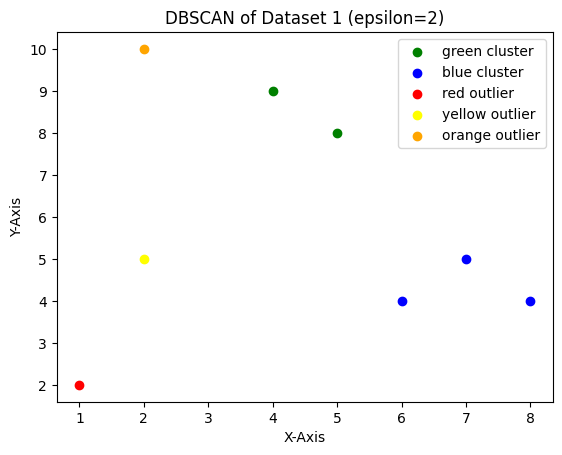

In [25]:
import matplotlib.pyplot as plt
points = [A1, A2, A3, A4, A5, A6, A7, A8]
epsilon = 2
minpoints = 2
clusters, noise = dbscan(points, epsilon, minpoints)
colors = ['green', 'blue']
for cluster, color in zip(clusters, colors):
  x_coordinates = [point[0] for point in cluster]
  y_coordinates = [point[1] for point in cluster]
  plt.scatter(x_coordinates, y_coordinates, label=f'{color} cluster', color=color, marker='o')
colors = ['red', 'yellow', 'orange', 'black']
for outlier, color in zip(noise, colors):
  x_coordinate = outlier[0]
  y_coordinate = outlier[1]
  plt.scatter(x_coordinate, y_coordinate, label=f'{color} outlier', color=color, marker='o')
plt.xlabel('X-Axis')
plt.ylabel('Y-Axis')
plt.title('DBSCAN of Dataset 1 (epsilon=2)')
plt.legend()
plt.show()

In the above figure we see two clusters, colored red and yellow, and three outliers, or points of noise, colored green, blue, and orange. This was DBSCAN performed with epsilon equal to 2. Epsilon as sqrt(10) is provided below.

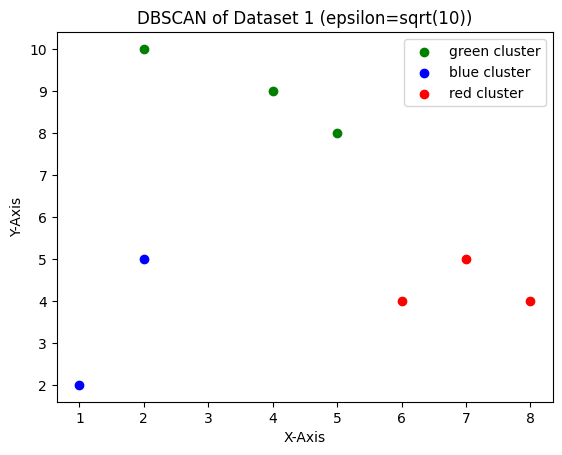

In [26]:
import numpy as np
points = [A1, A2, A3, A4, A5, A6, A7, A8]
epsilon = np.sqrt(10)
minpoints = 2
clusters, noise = dbscan(points, epsilon, minpoints)
colors = ['green', 'blue', 'red', 'yellow', 'orange', 'black']
for cluster, color in zip(clusters, colors):
  x_coordinates = [point[0] for point in cluster]
  y_coordinates = [point[1] for point in cluster]
  plt.scatter(x_coordinates, y_coordinates, label=f'{color} cluster', color=color, marker='o')
colors = ['red', 'yellow', 'orange', 'black']
for outlier, color in zip(noise, colors):
  x_coordinate = outlier[0]
  y_coordinate = outlier[1]
  plt.scatter(x_coordinate, y_coordinate, label=f'{color} outlier', color=color, marker='o')
plt.xlabel('X-Axis')
plt.ylabel('Y-Axis')
plt.title('DBSCAN of Dataset 1 (epsilon=sqrt(10))')
plt.legend()
plt.show()

**Question 13 - 14** Q13 - The final cluster plot for an epsilon of is provided above the figure above and entitled appropriately. Q14 - For an epsilon of sqrt(10), the final plot is depicted above and resembles the results of both the nearest neighbours clustering algorithms and the k-means algorithm.

**Verifying with sklearn (Part D)**

In [27]:
from sklearn.cluster import DBSCAN

points = [A1, A2, A3, A4, A5, A6, A7, A8]

db = DBSCAN(eps=2, min_samples=2).fit(points)
labels = db.labels_
print(f"The labels found, with epsilon=2, were: {labels}")

db = DBSCAN(eps=np.sqrt(10), min_samples=2).fit(points)
labels = db.labels_
print(f"The labels found, with epsilon=sqrt(10), were: {labels}")

The labels found, with epsilon=2, were: [-1 -1  0  1  0  0 -1  1]
The labels found, with epsilon=sqrt(10), were: [0 1 2 0 2 2 1 0]


From the above, we can acknowledge that sklearn confirmed our own DBSCAN algorithm. To interpret the labels, -1 indicates noise, and every subsequent number indicates the cluster to which it belongs. In this case, A1, A2, and A7 were outliers. A4 and A8 formed one cluster. And A3, A5, and A6 formed the other cluster. This is exactly what was found in the manually plotted data where epsilon was set to 2 and minpoints to 2.

Furthermore, DBSCAN also correponded even with epsilon changed to sqrt(10) as was done in the second trial.

**Part C - Dataset 2**

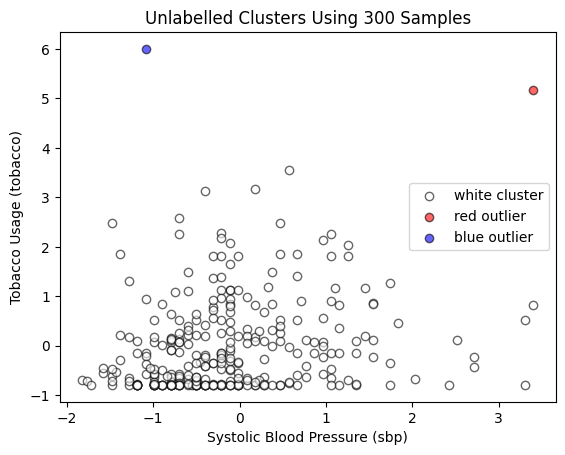

In [28]:
from itertools import cycle
# Train clusters on first 300 samples
epsilon = 2
minpoints = 2
points = [tuple(x) for x in normalized_data[['sbp', 'tobacco']].iloc[:300].values]
clusters, noise = dbscan(points, epsilon, minpoints)

# Plot resulting clusters
colors = ['white']
color_cycle = cycle(colors)
for cluster, color in zip(clusters, colors):
  x_coordinates = [point[0] for point in cluster]
  y_coordinates = [point[1] for point in cluster]
  plt.scatter(x_coordinates, y_coordinates, label = f'{color} cluster', color = color, alpha=0.6, edgecolor='k')
colors = ['red', 'blue', 'green']
for outlier, color in zip(noise, colors):
  x_coordinate = outlier[0]
  y_coordinate = outlier[1]
  plt.scatter(x_coordinate, y_coordinate, label = f'{color} outlier', color = color, alpha=0.6, edgecolor='k')
plt.xlabel('Systolic Blood Pressure (sbp)')
plt.ylabel('Tobacco Usage (tobacco)')
plt.title('Unlabelled Clusters Using 300 Samples')
plt.legend()
plt.show()

It appears as though of the three clustering algorithms, DBSCAN really struggled to accurately partition the data. While the former two were still able to force partitions in the mostly clumped data, DBSCAN was just too inviting of surrounding points to do so. And the accuracy will necessarily suffer for this.

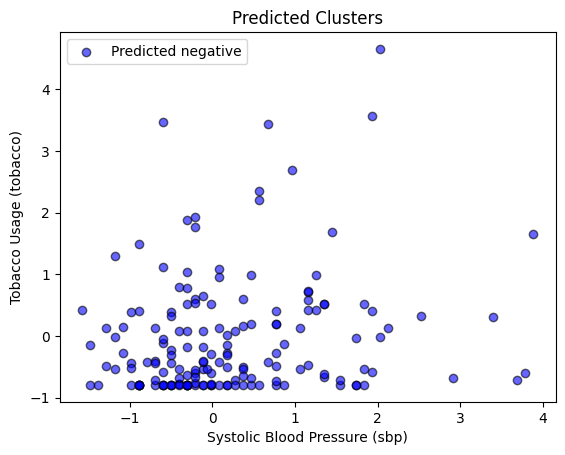

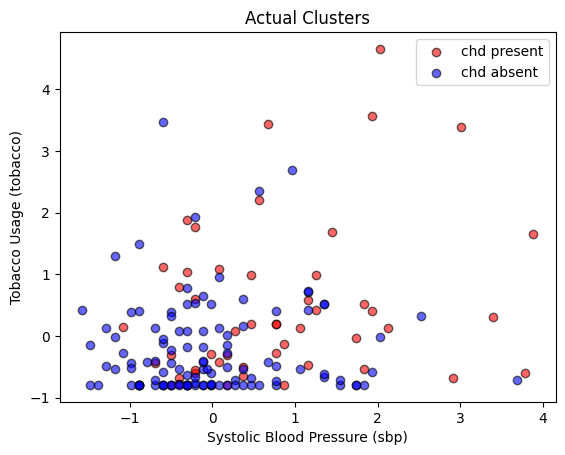

In [29]:
epsilon = 2
points = [tuple(x) for x in normalized_data[['sbp', 'tobacco']].iloc[-162:].values]
clusters, noise = dbscan_classification(clusters, points, epsilon)
colors = ['blue', 'red']
# Predicted data
for cluster, color in zip(clusters, colors):
  x_coordinates = [point[0] for point in cluster]
  y_coordinates = [point[1] for point in cluster]
  plt.scatter(x_coordinates, y_coordinates, label = 'Predicted negative', color = color, alpha=0.6, edgecolor='k')
plt.xlabel('Systolic Blood Pressure (sbp)')
plt.ylabel('Tobacco Usage (tobacco)')
plt.title('Predicted Clusters')
plt.legend()
plt.show()

# Plot actual chd data for comparison
sbp = normalized_data['sbp'].iloc[-162:].values
tobacco = normalized_data['tobacco'].iloc[-162:].values
chd = normalized_data['chd'].iloc[-162:].values

chd_present = [(sbp[i], tobacco[i]) for i in range(len(sbp)) if chd[i] == 1]
chd_absent = [(sbp[i], tobacco[i]) for i in range(len(sbp)) if chd[i] == 0]

# Plot chd present
plt.scatter(
  [point[0] for point in chd_present],
  [point[1] for point in chd_present],
  color='red', alpha=0.6, edgecolor='k', label='chd present'
)
# Plot chd absent
plt.scatter(
  [point[0] for point in chd_absent],
  [point[1] for point in chd_absent],
  color='blue', alpha=0.6, edgecolor='k', label='chd absent'
)
plt.xlabel('Systolic Blood Pressure (sbp)')
plt.ylabel('Tobacco Usage (tobacco)')
plt.title('Actual Clusters')
plt.legend()
plt.show()

As was mentioned, the DBSCAN algorithm could not partition the data no matter the manipulation of the parameters epsilon and minpoints. Thus, the one cluster was categorized as predicted negative since this would augment the accuracy calculation. As evidenced below, the accuracy was still seen to be relatively high, around 69%.

In [30]:
true_positive = 0
false_positive = 0
true_negative = 0
false_negative = 0

points = [tuple(x) for x in normalized_data[['sbp', 'tobacco']].iloc[-162:].values]
predicted_negative = [np.array(point) for point in points]
predicted_positive = []

for i in range(len(points)):
    point = np.array(points[i])
    # chd is present
    if chd[i] == 1:
        # Truthfully predicted positive
        if any((point == p).all() for p in predicted_positive):
            true_positive += 1
        # Falsely predicted negative
        else:
            false_negative += 1
    # chd is absent
    else:
        # Falsely predicted positive
        if any((point == p).all() for p in predicted_positive):
            false_positive += 1
        # Truthfully predicted negative
        else:
            true_negative += 1

print(f"True Negatives: {true_negative}")
print(f"True Positives: {true_positive}")
print(f"False Negatives: {false_negative}")
print(f"False Positives: {false_positive}")

accuracy = 100*(true_positive + true_negative)/(true_positive + true_negative + false_negative + false_positive)
print(f'The accuracy was calculated as approximately {accuracy:.2f}')

True Negatives: 112
True Positives: 0
False Negatives: 50
False Positives: 0
The accuracy was calculated as approximately 69.14


The results from sklearn's DBSCAN algorithm are presented below. With a little manipulation a partition formed in the data unlike the hand-made algorithm's results. The difference again, as with nearest neighbor clustering, is likely due to a difference in algorithm implementation.

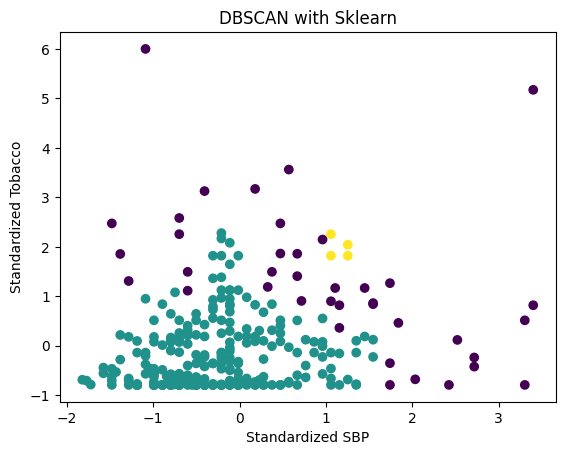

In [31]:
points = [tuple(x) for x in normalized_data[['sbp', 'tobacco']].iloc[:300].values]
points = np.array(points)

db = DBSCAN(eps=0.3, min_samples=4).fit(points)
labels = db.labels_

plt.scatter(points[:, 0], points[:, 1], c=labels, cmap='viridis')
plt.xlabel('Standardized SBP')
plt.ylabel('Standardized Tobacco')
plt.title('DBSCAN with Sklearn')
plt.show()

**Questions**

1) What are the different metrics used to evaluate the performance of different clustering algorithms?

There are a number of different metrics used to calculate the performance of clustering algorithms. An example could be the Adjusted Rand Index (ARI) which attempts to predict the similarity between the predicted clusters and true labels, where true labels are available. It ranges from -1 to 1 where 1 is a perfect match, -1 is a perfect mismatch, and 0 is random.

2) Instead of accuracy, what other ways can we evaluate the performance of three algorithms in lab 3?

Something like the Davies-Boulding Index (DBI) is an interesting metric suitable for analyzing the performance of unsupervised clustering algorithms. This index calculates the ratio between within-cluster scatter to between-cluster separation. In so doing, it attempts to provide information as to whether the algorithm is overclustering or underclustering based on the data provided.